In [1]:
import sklearn.ensemble as rf
import numpy as np
import matplotlib.pyplot as plt

In [2]:
with np.load("data/mnist/mnist.npz", allow_pickle=True) as f:
    xtrain, ytrain = f["x_train"], f["y_train"]
    xtest, ytest = f["x_test"], f["y_test"]

In [3]:
xtrain.shape

(60000, 28, 28)

In [4]:
ytrain.shape

(60000,)

In [5]:
xtest.shape

(10000, 28, 28)

In [6]:
xtrain = xtrain.reshape(-1, 28*28)
xtest = xtest.reshape(-1, 28*28)

In [10]:
model = rf.RandomForestClassifier()
model.fit(xtrain, ytrain)
print(model.score(xtest, ytest))

0.9688


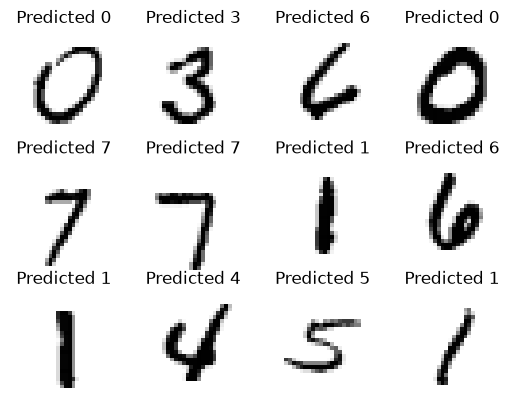

In [11]:
ypredicted = model.predict(xtest)

xtest = xtest.reshape(-1, 28, 28)
select = np.random.randint(xtest.shape[0], size=12)

for index, value in enumerate(select):
    plt.subplot(3, 4, index + 1)
    plt.axis("off")
    plt.imshow(xtest[value], cmap=plt.cm.gray_r, interpolation="nearest")
    plt.title(f"Predicted {ypredicted[value]}")
plt.show()

In [12]:
errors = ytest != ypredicted
xerrors = xtest[errors]
yerrors = ypredicted[errors]

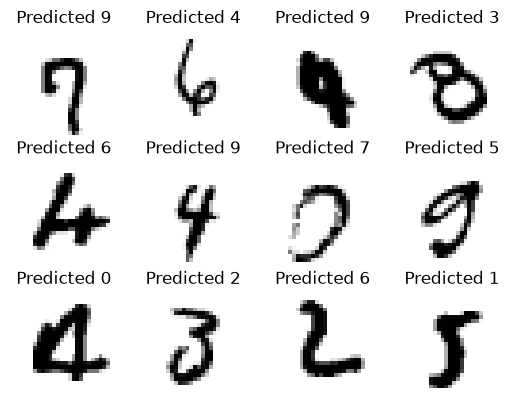

In [13]:
select = np.random.randint(xerrors.shape[0], size=12)

for index, value in enumerate(select):
    plt.subplot(3, 4, index + 1)
    plt.axis("off")
    plt.imshow(xerrors[value], cmap=plt.cm.gray_r, interpolation="nearest")
    plt.title(f"Predicted {yerrors[value]}")
plt.show()

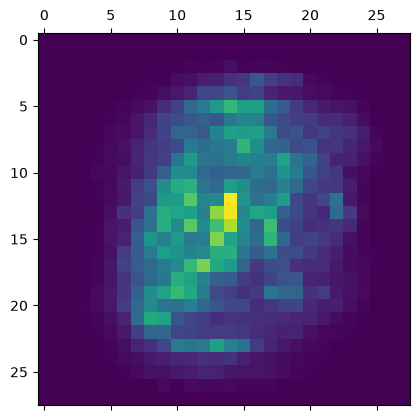

In [14]:
plt.matshow(model.feature_importances_.reshape(28,28))
plt.show()